In [2]:
import os
import numpy as np
import pandas as pd
import re

In [3]:
def build_image_dict(root="All_Dataset"):
    image_dict = {}

    # Pattern for big TIFFs: something_1.tif, something_23.tif, etc.
    big_pattern = re.compile(r"(.+?)_(\d+)\.tif$", re.IGNORECASE)

    # Pattern for small-folder: single cilia image01, image02, etc.
    small_folder_pattern = re.compile(r"single cilia image(\d+)", re.IGNORECASE)

    for exp in os.listdir(root):
        exp_path = os.path.join(root, exp)
        if not os.path.isdir(exp_path):
            continue

        for condition in os.listdir(exp_path):
            cond_path = os.path.join(exp_path, condition)
            if not os.path.isdir(cond_path):
                continue

            # First collect big images and small folders in this condition
            big_images = {}
            small_folders = {}

            for item in os.listdir(cond_path):
                item_path = os.path.join(cond_path, item)

                # Match big tifs
                m = big_pattern.match(item)
                if m:
                    base, num = m.group(1), int(m.group(2))
                    big_images[num] = item  # store filename
                    continue

                # Match small-image folder
                f = small_folder_pattern.match(item)
                if f and os.path.isdir(item_path):
                    folder_idx = int(f.group(1))  # e.g. "01" → 1
                    small_folders[folder_idx] = item
                    continue

            # Now pair big images with their small folders
            for num, big_name in big_images.items():
                rel_big = f"{exp}/{condition}/{big_name}"

                # Try to find matching small folder
                if num in small_folders:
                    folder_name = small_folders[num]
                    folder_rel_path = os.path.join(exp, condition, folder_name)

                    # Collect small tifs inside folder
                    small_list = []
                    folder_full_path = os.path.join(root, folder_rel_path)

                    for f in os.listdir(folder_full_path):
                        if f.lower().endswith(".tif"):
                            small_list.append(
                                os.path.join(exp, condition, folder_name, f)
                            )

                    image_dict[rel_big] = small_list

                else:
                    image_dict[rel_big] = []  # no matching folder found

    return image_dict


# Example usage
# image_map = build_image_dict("/group/jug/aman/Cilia_Datasets/01_All_Data")


In [4]:
import os
import re
import numpy as np
from tifffile import imread
import numpy as np
import matplotlib.pyplot as plt

def plot_channels_composite(img, channels, colors=None, title="Composite"):
    """
    img: (H, W, C) numpy array
    channels: list of channel indices to display
    colors: optional list of colors; if None, auto-assigns BGRM
    """
    H, W, C = img.shape
    composite = np.zeros((H, W, 3), dtype=float)

    # Automatic color mapping
    default_colors = ['B', 'G', 'R', 'M']
    rgb_map = {'R':[1,0,0], 'G':[0,1,0], 'B':[0,0,1], 'M':[1,0,1]}
    if colors is None:
        colors = [default_colors[ch % len(default_colors)] for ch in channels]

    for ch, col in zip(channels, colors):
        d = img[:, :, ch].astype(float)
        # if d.max() > 0:
        d /= d.max()  # normalize
        composite += d[:, :, None] * rgb_map[col]

    plt.imshow(np.clip(composite, 0, 1))
    plt.title(title)
    plt.axis('off')


def load_small_images(folder_full_path):
    """
    Loads all .tif files inside a folder.
    Returns two LISTS (normal and cq).
    Never stacks, never crops, never resizes.
    """

    normal_imgs = []
    cq_imgs = []

    if not os.path.isdir(folder_full_path):
        return normal_imgs, cq_imgs

    for fname in sorted(os.listdir(folder_full_path)):
        if not fname.lower().endswith(".tif"):
            continue

        full_path = os.path.join(folder_full_path, fname)

        try:
            img = imread(full_path)
        except Exception as e:
            print(f"⚠️ Skipping unreadable file: {full_path}", e)
            continue

        if "_CQ" in fname or "_CQP" in fname:
            cq_imgs.append(img)
        else:
            normal_imgs.append(img)

    return normal_imgs, cq_imgs

def parse_dataset_to_stacks(root="All_Dataset"):
    """
    Traverses dataset, pairs big images with small-image folders.
    Loads small images but DOES NOT stack (returns lists).
    """

    image_data = {}

    big_pattern = re.compile(r"(.+?)_(\d+)\.tif$", re.IGNORECASE)
    small_folder_pattern = re.compile(r"single cilia image(\d+)", re.IGNORECASE)

    for exp in os.listdir(root):
        exp_path = os.path.join(root, exp)
        if not os.path.isdir(exp_path):
            continue

        for condition in os.listdir(exp_path):
            cond_path = os.path.join(exp_path, condition)
            if not os.path.isdir(cond_path):
                continue

            big_images = {}
            small_folders = {}

            # Scan the condition folder
            for item in os.listdir(cond_path):
                item_path = os.path.join(cond_path, item)

                # Big .tif
                m = big_pattern.match(item)
                if m:
                    num = int(m.group(2))
                    big_images[num] = item
                    continue

                # Small-image folder
                f = small_folder_pattern.match(item)
                if f and os.path.isdir(item_path):
                    idx = int(f.group(1))  # "01" → 1
                    small_folders[idx] = item
                    continue

            # Pair big→small
            for num, big_name in big_images.items():
                rel_big = f"{exp}/{condition}/{big_name}"

                if num in small_folders:
                    folder_name = small_folders[num]
                    folder_rel = os.path.join(exp, condition, folder_name)
                    folder_full = os.path.join(root, folder_rel)

                    normal_list, cq_list = load_small_images(folder_full)

                else:
                    normal_list, cq_list = [], []

                image_data[rel_big] = {
                    "normal": normal_list,
                    "cq": cq_list
                }

    return image_data

def get_mean_and_max_projection(image_stacks):
    normal_imgs = []
    cq_imgs = []
    for key in sorted(image_stacks.keys()):
        try:
            normal_imgs.append(np.array(image_stacks[key]["normal"]))
            cq_imgs.append(np.array(image_stacks[key]["cq"]))
        except Exception as e:
            print(f"⚠️ Error processing {key}: {e}") 
            print(len(image_stacks[key]["cq"]))
            # for i in range(len(image_stacks[key]["cq"])):
            #     print(image_stacks[key]["cq"][i].shape)
    # Only transpose arrays that are non-empty
    nm = [np.transpose(x, (1,0,3,4,2)) for x in normal_imgs if x.size > 0]
    nm_avg = np.concatenate([np.mean(x, axis=0) for x in nm], axis=0)
    nm_max = np.concatenate([np.max(x, axis=0) for x in nm], axis=0)
    return nm_avg, nm_max


In [5]:
image_stacks_dp = parse_dataset_to_stacks("/group/jug/aman/Cilia_Datasets/Double_Puncta")
image_stacks_sp = parse_dataset_to_stacks("/group/jug/aman/Cilia_Datasets/Single_Puncta")
nm_avg_dp, nm_max_dp = get_mean_and_max_projection(image_stacks_dp)
nm_avg_sp, nm_max_sp = get_mean_and_max_projection(image_stacks_sp)

⚠️ Error processing CCDC92/Pkhd1 KO/KO_7.tif: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (117, 15) + inhomogeneous part.
117


In [9]:
import tifffile as tf
tf.imwrite("double_puncta_mean_projection.tif", nm_avg_dp.astype(np.float32))
tf.imwrite("double_puncta_max_projection.tif", nm_max_dp.astype(np.float32))

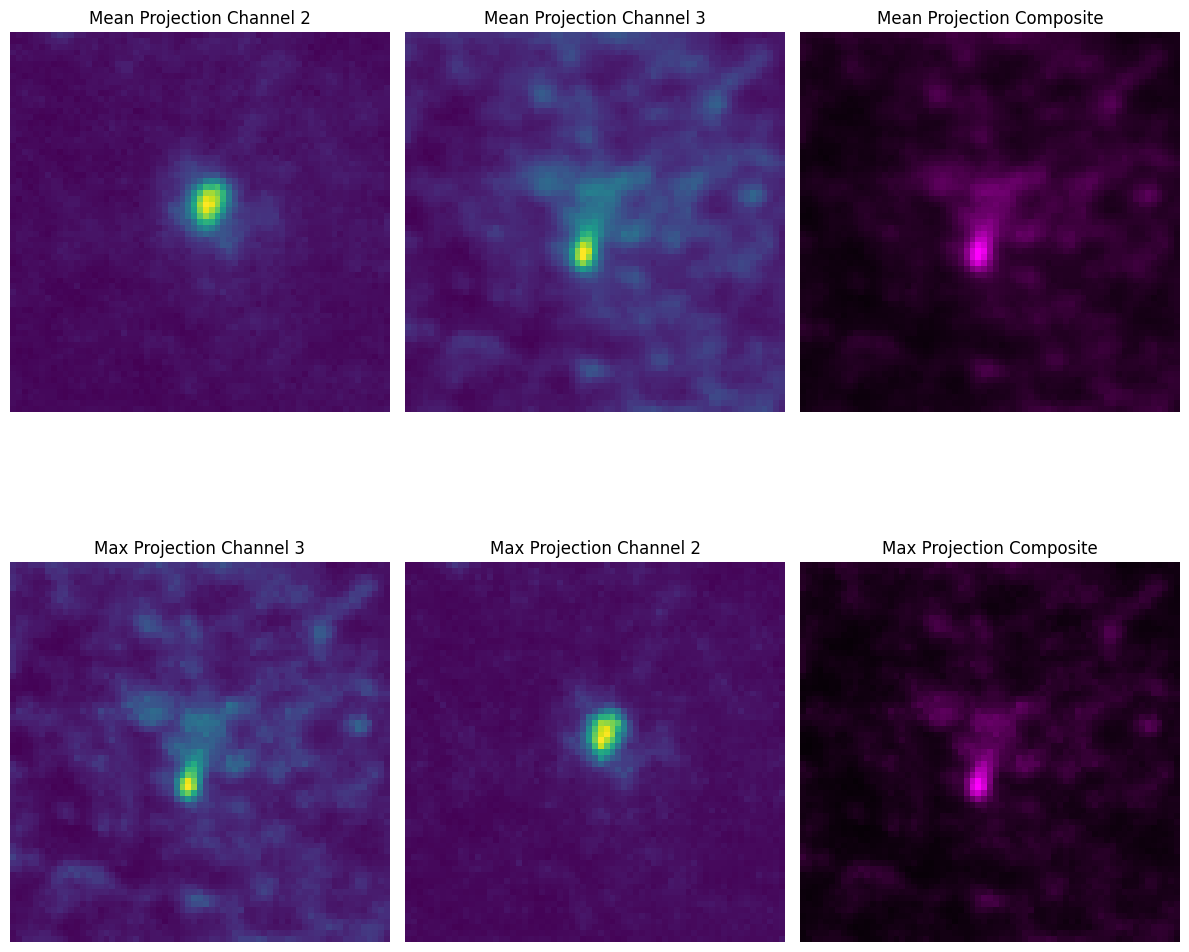

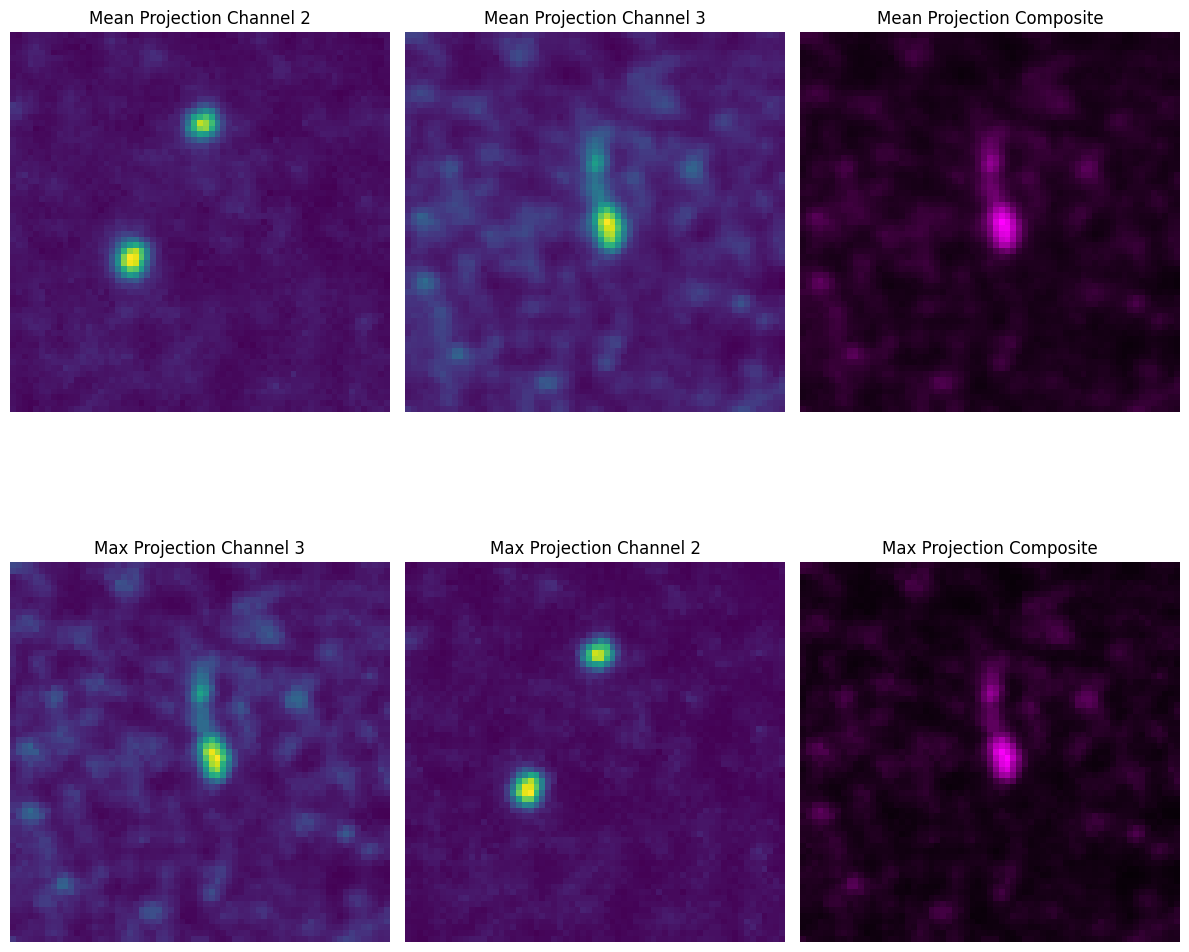

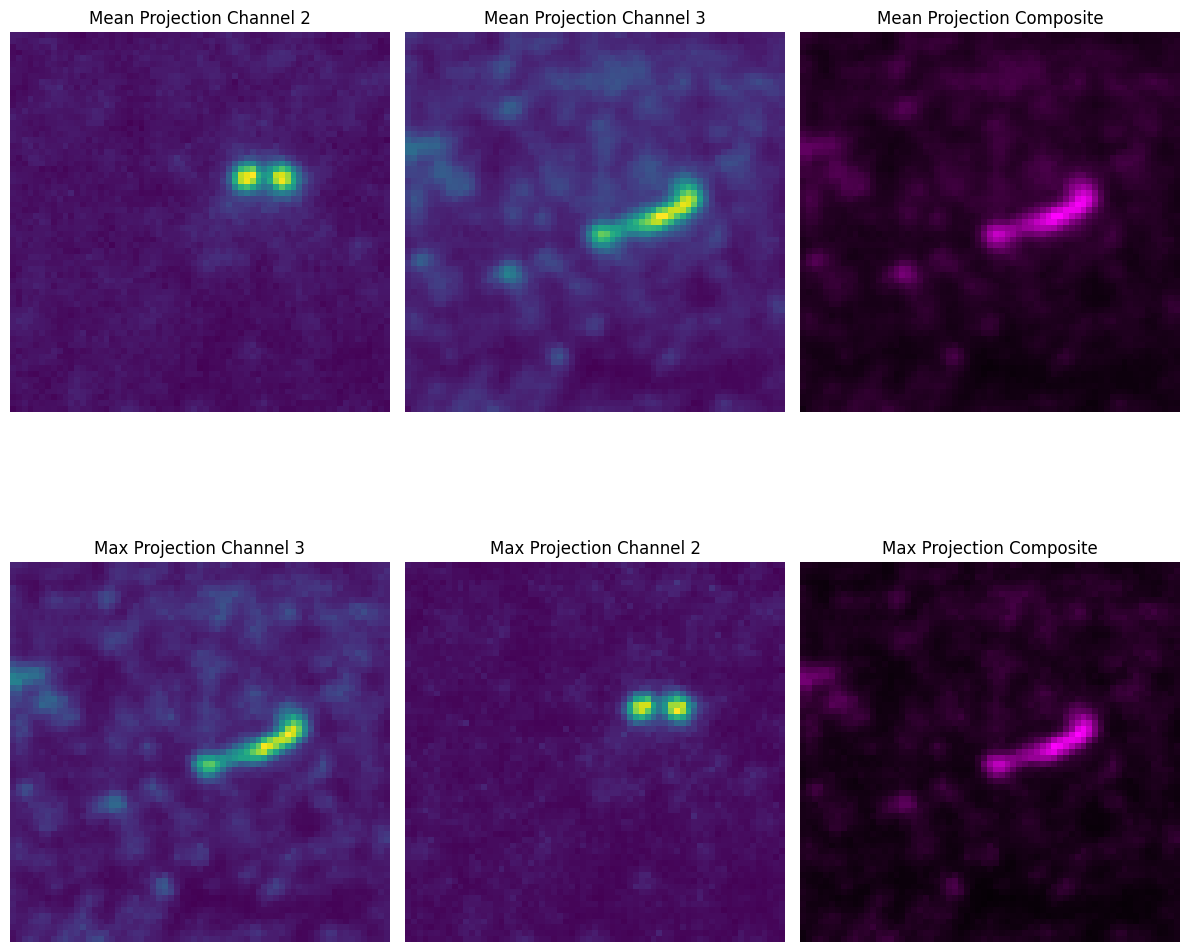

In [6]:
import matplotlib.pyplot as plt
import random

# Randomly select 3 indices from your 5 images
indices = random.sample(range(len(nm_avg_dp)), 3)

for i in indices:
    plt.figure(figsize=(12, 12))  # wider to look good on screen

    plt.subplot(2,3,1)
    plt.title("Mean Projection Channel 2")
    plt.imshow(nm_avg_dp[i][:,:,2])
    plt.axis('off')

    plt.subplot(2,3,2)
    plt.title("Mean Projection Channel 3")
    plt.imshow(nm_avg_dp[i][:,:,3])
    plt.axis('off')
    
    plt.subplot(2,3,3)
    # plot_channels_composite(nm_avg_dp[i], channels=[1, 2, 3]
    # plot_channels_composite(nm_avg_dp[i], channels=[2, 3],
    plot_channels_composite(nm_avg_dp[i], channels=[3],
                            title="Mean Projection Composite")

    plt.subplot(2,3,4)
    plt.title("Max Projection Channel 3")
    plt.imshow(nm_max_dp[i][:,:,3])
    plt.axis('off')
    
    plt.subplot(2,3,5)
    plt.title("Max Projection Channel 2")
    plt.imshow(nm_max_dp[i][:,:,2])
    plt.axis('off')

    plt.subplot(2,3,6)
    # plot_channels_composite(nm_max_dp[i], channels=[1, 2, 3], colors=['G', 'R', 'M'],
    # plot_channels_composite(nm_max_dp[i], channels=[2, 3],
    plot_channels_composite(nm_max_dp[i], channels=[3],
                            title="Max Projection Composite")

    plt.tight_layout()
    plt.show()


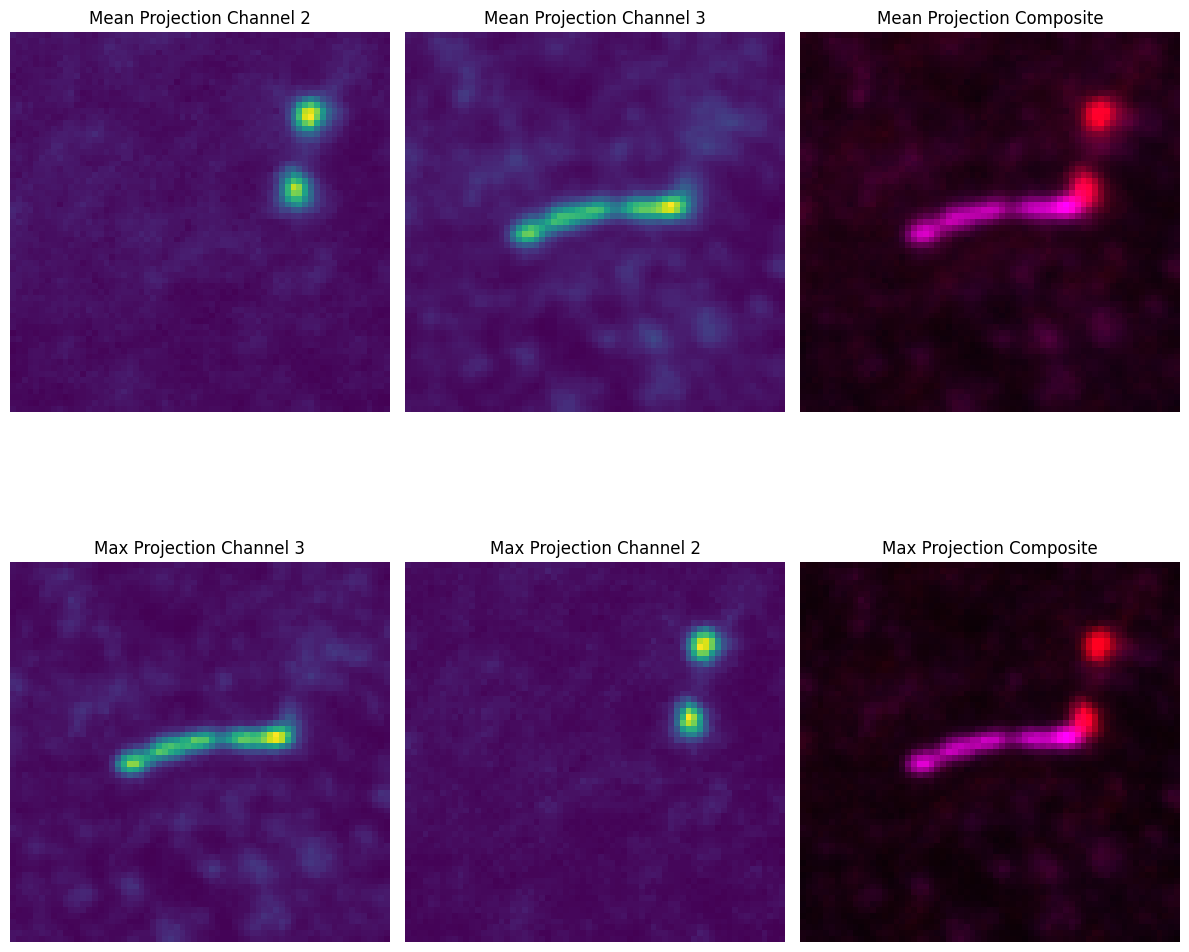

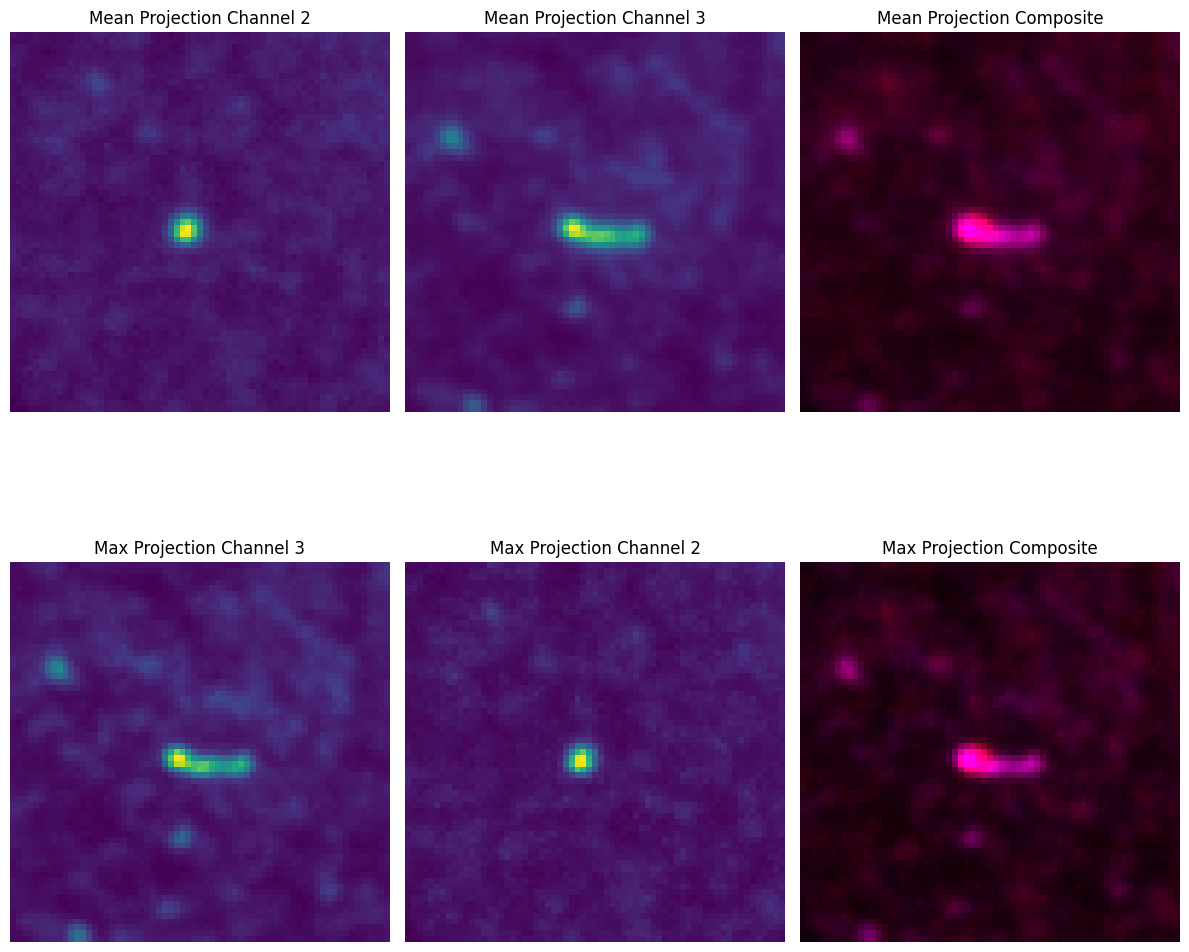

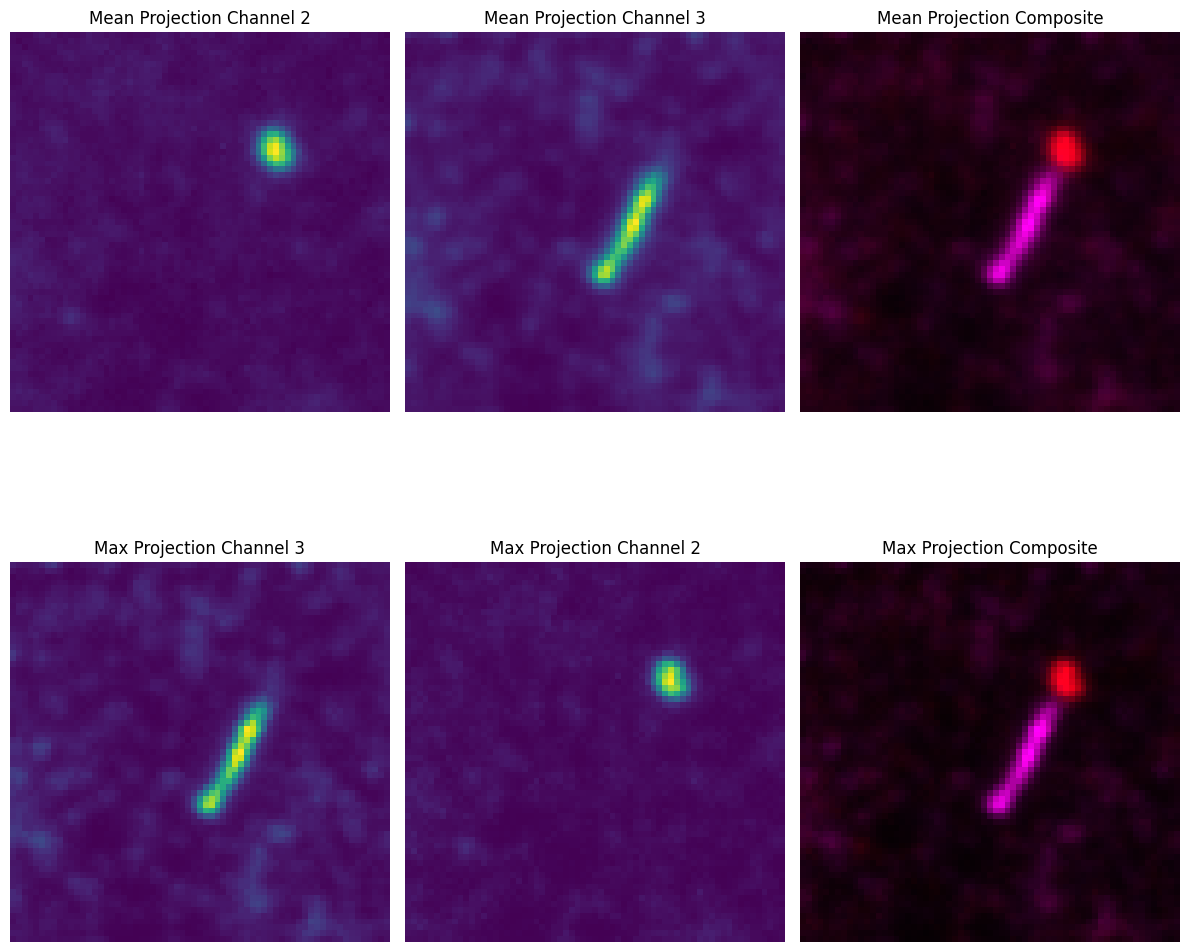

In [7]:
import matplotlib.pyplot as plt
import random

# Randomly select 3 indices from your 5 images
indices = random.sample(range(len(nm_avg_sp)), 3)

for i in indices:
    plt.figure(figsize=(12, 12))  # wider to look good on screen

    plt.subplot(2,3,1)
    plt.title("Mean Projection Channel 2")
    plt.imshow(nm_avg_sp[i][:,:,2])
    plt.axis('off')

    plt.subplot(2,3,2)
    plt.title("Mean Projection Channel 3")
    plt.imshow(nm_avg_sp[i][:,:,3])
    plt.axis('off')
    
    plt.subplot(2,3,3)
    # plot_channels_composite(nm_avg_sp[i], channels=[1, 2, 3]
    plot_channels_composite(nm_avg_sp[i], channels=[2, 3],
    # plot_channels_composite(nm_avg_sp[i], channels=[3],
                            title="Mean Projection Composite")

    plt.subplot(2,3,4)
    plt.title("Max Projection Channel 3")
    plt.imshow(nm_max_sp[i][:,:,3])
    plt.axis('off')
    
    plt.subplot(2,3,5)
    plt.title("Max Projection Channel 2")
    plt.imshow(nm_max_sp[i][:,:,2])
    plt.axis('off')

    plt.subplot(2,3,6)
    # plot_channels_composite(nm_max_sp[i], channels=[1, 2, 3], colors=['G', 'R', 'M'],
    plot_channels_composite(nm_max_sp[i], channels=[2, 3],
    # plot_channels_composite(nm_max_sp[i], channels=[3],
                            title="Max Projection Composite")

    plt.tight_layout()
    plt.show()
